In [1]:
import torch

# 1. 檢查 PyTorch 版本
print(f"PyTorch Version: {torch.__version__}")

# 2. 檢查 GPU 是否可用 (對應 tf.test.is_gpu_available())
is_gpu_available = torch.cuda.is_available()
print(f"GPU Available: {is_gpu_available}")

# 3. (額外建議) 如果有抓到 GPU，印出顯卡型號確認
if is_gpu_available:
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

PyTorch Version: 2.9.1+cu130
GPU Available: True
Device Name: NVIDIA GeForce RTX 3090


In [2]:
# import需要的模組

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from matplotlib import pyplot as plt
import time
import joblib

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
# 讀取data

train_df = pd.read_csv('plastic_data.csv')
train_df.shape

(3007, 92)

In [4]:
# 讀取data前半部的編織物結構0101矩陣當作圖像輸入(woven structure)，並將圖像輸入分成train、test兩部分

x_train_image_data = train_df.values[:,0:25]
x_train_image_data = np.array(x_train_image_data)

In [5]:
# 讀取data後半部的纖維、樹酯材料、幾何參數，並將性質輸入分成train、test

x_train_data = train_df.values[:,25:50]
x_train_data = np.array(x_train_data)

In [6]:
# 讀取data最後部分的模擬出來的編織物機械性質，並將機械性質輸出分成train、test

y_train_data = train_df.values[:,52:]
y_train_data = np.array(y_train_data)

In [7]:
x_angle_data_new = train_df.values[3000:-2,25:26]
y_data_new = train_df.values[3000:-2,52:]

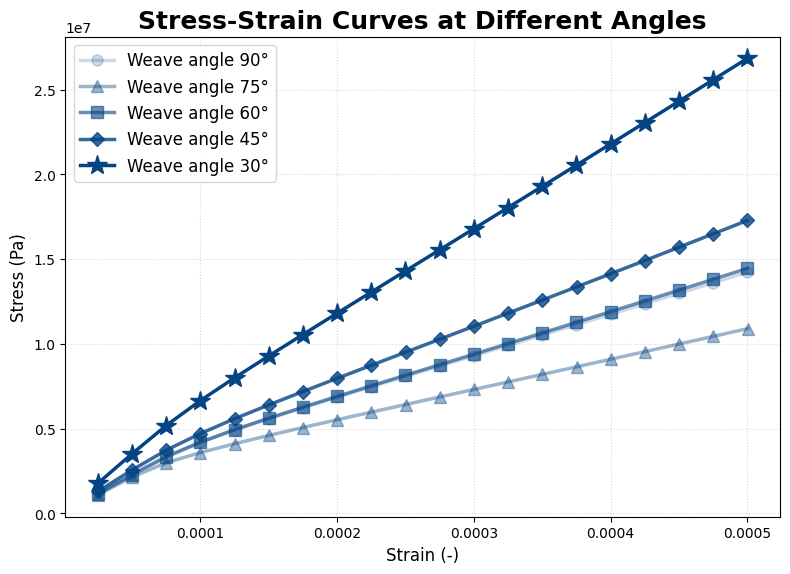

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 提取 Satin 編織的 5 種角度資料 
x_subset = x_angle_data_new[-5:].flatten()
y_subset = y_data_new[-5:, :]

# 2. 轉換角度 (實際角度 = 90 - 讀取角度)
# 轉換後的陣列順序為：[90, 75, 60, 45, 30]
angles_converted = 90 - x_subset

# 3. 建立畫布與設定圖表大小
plt.figure(figsize=(8, 6))

# 定義單一基礎顏色
base_color = "#054483" 

markers = ['o', '^', 's', 'D', '*']

# **新增：建立一個 List 來自由設定 5 個角度對應的標記大小**
# **你可以直接修改這 5 個數字，順序對應 90, 75, 60, 45, 30 度**
# **marker_sizes = [6, 7, 8, 10, 15]**
marker_sizes = [8, 8, 8, 7, 15]

# 4. 使用迴圈依序繪製 5 條應力應變曲線
for i in range(5):
    curve_data = y_subset[i]
    current_angle = angles_converted[i]
    
    # 動態計算 alpha 值：30 度為 1.0，90 度為 0.2
    alpha_val = 1.0 - ((current_angle - 30) / 60.0) * 0.8
    alpha_val = max(0.1, min(1.0, alpha_val))
    
    # 提取應力與應變陣列
    stress = np.array(curve_data[0::2], dtype=float)
    strain = np.array(curve_data[1::2], dtype=float)
    
    plt.plot(strain, stress, 
             label=f'Weave angle {current_angle:.0f}°', 
             color=base_color, 
             alpha=alpha_val, 
             linestyle='-', 
             linewidth=2.5,
             marker=markers[i],
             # **修改：從你自訂的 List 中讀取大小**
             # **markersize=marker_sizes[i]**
             markersize=marker_sizes[i]) 

# 5. 設定圖表標籤與格式
plt.title('Stress-Strain Curves at Different Angles', fontsize=18, fontweight='bold')
plt.xlabel('Strain (-)', fontsize=12)
plt.ylabel('Stress (Pa)', fontsize=12) 

# 開啟網格線
plt.grid(True, linestyle=':', alpha=0.5)

# 顯示圖例
plt.legend(loc='best', fontsize=12)

# 自動調整版面配置
plt.tight_layout()

# 顯示圖表
plt.show()

目前資料筆數: 3007
預計擴增筆數: 493
擴增完成！最終參數資料筆數: 3500
擴增完成！最終影像資料筆數: 3500


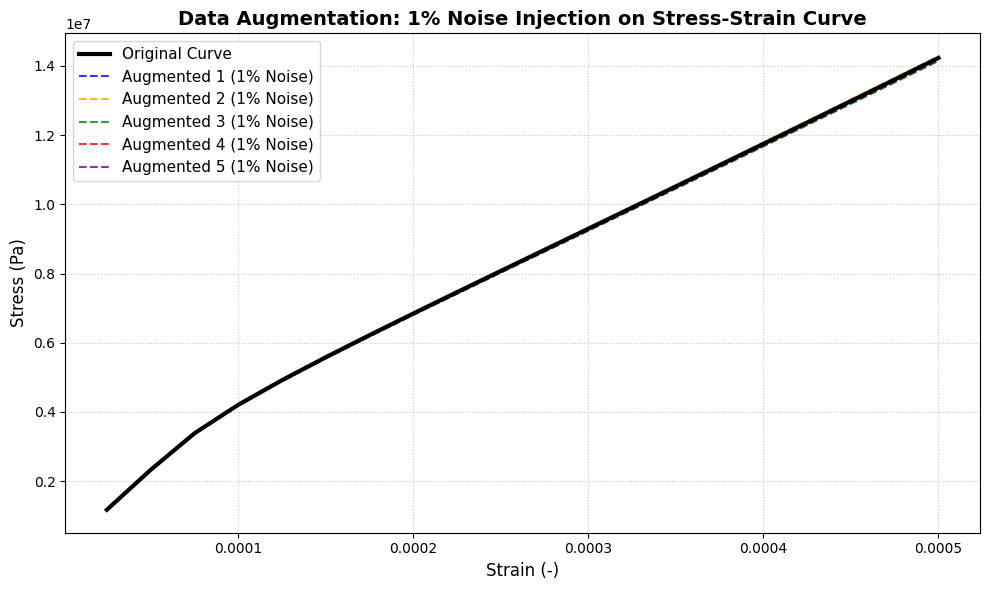

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 假設你的資料變數為 x_train_data, x_train_image_data 與 y_train_data
# 目前長度應為 3007

# 1. 設定擴增目標
target_size = 3500
current_size = len(x_train_data)
num_to_generate = target_size - current_size # 需要產生 493 筆

print(f"目前資料筆數: {current_size}")
print(f"預計擴增筆數: {num_to_generate}")

if num_to_generate > 0:
    # 2. 提取最新的 7 筆資料作為「基底 (Base)」
    x_base = x_train_data[-7:]
    # **新增：提取影像資料的基底**
    # **x_image_base = x_train_image_data[-7:]**
    x_image_base = x_train_image_data[-7:]
    y_base = y_train_data[-7:]
    
    x_aug_list = []
    # **新增：建立影像擴增的空列表**
    # **x_image_aug_list = []**
    x_image_aug_list = []
    y_aug_list = []
    
    # 3. 隨機從這 7 筆中抽取 493 次來進行擴增
    base_indices = np.random.choice(len(x_base), size=num_to_generate, replace=True)
    
    for idx in base_indices:
        # X 參數與影像完全不變，直接複製
        x_aug = np.copy(x_base[idx])
        # **新增：複製影像資料**
        # **x_image_aug = np.copy(x_image_base[idx])**
        x_image_aug = np.copy(x_image_base[idx])
        y_aug = np.copy(y_base[idx])
        
        # 【推薦做法】全域縮放噪音：整條曲線乘上同一個微小的隨機比例 (保持平滑)
        global_noise_ratio = np.random.uniform(-0.01, 0.01)
        y_aug[0::2] = y_aug[0::2] * (1 + global_noise_ratio)
        
        x_aug_list.append(x_aug)
        # **新增：將複製的影像加入列表中**
        # **x_image_aug_list.append(x_image_aug)**
        x_image_aug_list.append(x_image_aug)
        y_aug_list.append(y_aug)
    
    # 4. 將擴增的資料與原始資料合併
    # **修改：使用 np.concatenate(..., axis=0) 取代 vstack，以確保影像的高維度陣列能正確沿著樣本軸拼接**
    x_train_data_expanded = np.concatenate((x_train_data, np.array(x_aug_list)), axis=0)
    # **新增：合併影像資料**
    # **x_train_image_data_expanded = np.concatenate((x_train_image_data, np.array(x_image_aug_list)), axis=0)**
    x_train_image_data_expanded = np.concatenate((x_train_image_data, np.array(x_image_aug_list)), axis=0)
    y_train_data_expanded = np.concatenate((y_train_data, np.array(y_aug_list)), axis=0)
    
    print(f"擴增完成！最終參數資料筆數: {len(x_train_data_expanded)}")
    print(f"擴增完成！最終影像資料筆數: {len(x_train_image_data_expanded)}") # **新增檢查影像長度**

    # 5. 繪圖比較 (加入噪音前後的差異)
    plt.figure(figsize=(10, 6))

    original_y = y_base[0]
    original_stress = original_y[0::2]
    original_strain = original_y[1::2]

    plt.plot(original_strain, original_stress, 
             label='Original Curve', color='black', linewidth=3, zorder=5)

    plot_count = 0
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    
    for i, base_idx in enumerate(base_indices):
        if base_idx == 0 and plot_count < 5:
            aug_y = y_aug_list[i]
            aug_stress = aug_y[0::2]
            aug_strain = aug_y[1::2]
            
            plt.plot(aug_strain, aug_stress, 
                     label=f'Augmented {plot_count+1} (1% Noise)', 
                     color=colors[plot_count], linestyle='--', linewidth=1.5, alpha=0.8)
            plot_count += 1

    plt.title('Data Augmentation: 1% Noise Injection on Stress-Strain Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Strain (-)', fontsize=12)
    plt.ylabel('Stress (Pa)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='best', fontsize=11)
    plt.tight_layout()
    plt.show()

else:
    print("目標筆數不大於目前筆數，不需擴增。")

In [10]:
x_train_image_data = x_train_image_data_expanded.reshape(x_train_image_data_expanded.shape[0],5,5,1)

x_train_image, x_test_image = train_test_split(x_train_image_data, test_size=0.15, random_state=8)

In [11]:
X_minMax = preprocessing.MinMaxScaler(feature_range=(0, 1)).fit(x_train_data_expanded)
x_train_data = X_minMax.transform(x_train_data_expanded)

x_train, x_test = train_test_split(x_train_data, test_size=0.15, random_state=8)
x_train_data.shape

(3500, 25)

In [12]:
joblib.dump(X_minMax, "plastic_input_scaler.pkl")

['plastic_input_scaler.pkl']

In [13]:
Y_minMax = preprocessing.MinMaxScaler(feature_range=(0, 1)).fit(y_train_data_expanded)
y_train_data = Y_minMax.transform(y_train_data_expanded)

y_train, y_test = train_test_split(y_train_data, test_size=0.15, random_state=8)
y_train_data.shape

(3500, 40)

In [14]:
joblib.dump(Y_minMax, "plastic_output_scaler.pkl")

['plastic_output_scaler.pkl']

In [15]:
# class PlasticModel(nn.Module):
#     def __init__(self):
#         super(PlasticModel, self).__init__()

#         # --- 1. Image Branch (圖像路徑 - 處理編織矩陣) ---
#         # 輸入形狀: (Batch, 1, 5, 5) -> Flatten 後為 25 維
#         # 這部分結構維持不變
#         self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=2, stride=2, padding=1)
#         self.relu = nn.ReLU()
#         self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=2, stride=2, padding=1)
#         self.dropout1 = nn.Dropout(0.2)
#         self.conv3 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=2, stride=2, padding=0)
#         self.conv4 = nn.Conv2d(in_channels=2, out_channels=2, kernel_size=2, stride=1, padding=1)
#         self.pool1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
        
#         self.flatten = nn.Flatten()
        
#         # 經過卷積與池化後，特徵維度維持為 18，與您之前的修正一致
#         self.img_dense_block = nn.Sequential(
#             nn.Linear(18, 960), 
#             nn.ReLU(),
#             nn.Linear(960, 480),
#             nn.ReLU(),
#             nn.Linear(480, 240),
#             nn.ReLU(),
#             nn.Linear(240, 120),
#             nn.ReLU()
#         )

#         # --- 2. Info Branch (性質路徑 - 處理幾何+材料+塑性) ---
#         # [修改點 1]: 輸入維度改為 25
#         # 原始 21 (幾何4 + 樹脂3 + 纖維14) + 新增 4 (塑性應力/應變參數) = 25
#         self.info_dense_block = nn.Sequential(
#             nn.Linear(25, 64),  # <--- Modified here
#             nn.ReLU(),
#             nn.Linear(64, 48),
#             nn.ReLU(),
#             nn.Linear(48, 36),
#             nn.ReLU(),
#             nn.Linear(36, 24),  # 輸出維持 24，以便與圖像特徵 (120) 結合
#             nn.ReLU()
#         )

#         # --- 3. Combined Path (結合後路徑) ---
#         # 結合後維度: 120 (Image) + 24 (Info) = 144
#         # Reshape 成 12x12 進入卷積
#         self.c_conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=2, stride=1, padding=0)
#         self.c_conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=2, stride=1, padding=1)
#         self.c_conv3 = nn.Conv2d(in_channels=16, out_channels=12, kernel_size=2, stride=1, padding=1)
        
#         # Flatten 後維度維持 2028 (12 * 13 * 13)
#         self.final_dense_block = nn.Sequential(
#             nn.Linear(12 * 13 * 13, 1920), 
#             nn.ReLU(),
#             nn.Linear(1920, 960),
#             nn.ReLU(),
#             nn.Linear(960, 480),
#             nn.ReLU(),
#             nn.Dropout(0.1),
#             nn.Linear(480, 240),
#             nn.ReLU(),
#             nn.Linear(240, 120),
#             nn.ReLU(),
#             # [修改點 2]: 輸出維度改為 40
#             # 代表 20 個點的 (Stress, Strain) 座標
#             nn.Linear(120, 40)  # <--- Modified here
#         )

#     def forward(self, img_input, info_input):
#         # 確保圖片維度正確 (Batch, 1, 5, 5)
#         if img_input.shape[-1] == 1: 
#             x1 = img_input.permute(0, 3, 1, 2)
#         else:
#             x1 = img_input
            
#         x1 = self.relu(self.conv1(x1))
#         x1 = self.relu(self.conv2(x1))
#         x1 = self.dropout1(x1)
#         x1 = self.relu(self.conv3(x1))
#         x1 = self.relu(self.conv4(x1))
#         x1 = self.pool1(x1)
#         x1 = self.flatten(x1)
        
#         x1 = self.img_dense_block(x1)
        
#         # 這裡 info_input 預期是 (Batch, 25)
#         x2 = self.info_dense_block(info_input)

#         combined = torch.cat((x1, x2), dim=1)
#         combined = combined.view(-1, 1, 12, 12)

#         c = self.relu(self.c_conv1(combined))
#         c = self.relu(self.c_conv2(c))
#         c = self.relu(self.c_conv3(c))
#         c = self.flatten(c)
        
#         output = self.final_dense_block(c)
#         return output

In [15]:
class PlasticModel(nn.Module):
    def __init__(self):
        super(PlasticModel, self).__init__()

        # ==========================================
        # 1. Image Branch (維持不變)
        # ==========================================
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=2, stride=2, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=2, stride=2, padding=1)
        self.dropout1 = nn.Dropout(0.2)
        self.conv3 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=2, stride=2, padding=0)
        self.conv4 = nn.Conv2d(in_channels=2, out_channels=2, kernel_size=2, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
        
        self.flatten = nn.Flatten()
        
        self.img_dense_block = nn.Sequential(
            nn.Linear(18, 960), 
            nn.ReLU(),
            nn.Linear(960, 480),
            nn.ReLU(),
            nn.Linear(480, 240),
            nn.ReLU(),
            nn.Linear(240, 120),
            nn.ReLU()
        )

        # ==========================================
        # 2. Info Branch (維持不變)
        # ==========================================
        self.info_dense_block = nn.Sequential(
            nn.Linear(25, 64), 
            nn.ReLU(),
            nn.Linear(64, 48),
            nn.ReLU(),
            nn.Linear(48, 36),
            nn.ReLU(),
            nn.Linear(36, 24), 
            nn.ReLU()
        )

        # ==========================================
        # 3. Combined Path (重大修改)
        # ==========================================
        # 這裡不再轉回圖片，而是使用 MLP 直接融合
        # 輸入維度: 120 (Image特徵) + 24 (Info特徵) = 144
        
        self.final_dense_block = nn.Sequential(
            # Layer 1: 144 -> 512
            nn.Linear(144, 512),
            nn.ReLU(),
            nn.Dropout(0.1),       # [優化] 防止過擬合
            
            # Layer 2: 512 -> 256
            nn.Linear(512, 256),
            nn.ReLU(),
            
            # Layer 3: 256 -> 128
            nn.Linear(256, 128),
            nn.ReLU(),
           
            # Output Layer: 128 -> 40
            # 輸出 20 個點的 (Stress, Strain) 座標
            nn.Linear(128, 40)
        )

    def forward(self, img_input, info_input):
        # --- Image Branch ---
        if img_input.shape[-1] == 1: 
            x1 = img_input.permute(0, 3, 1, 2)
        else:
            x1 = img_input
            
        x1 = self.relu(self.conv1(x1))
        x1 = self.relu(self.conv2(x1))
        x1 = self.dropout1(x1)
        x1 = self.relu(self.conv3(x1))
        x1 = self.relu(self.conv4(x1))
        x1 = self.pool1(x1)
        x1 = self.flatten(x1)
        
        x1 = self.img_dense_block(x1) # Output: (Batch, 120)
        
        # --- Info Branch ---
        x2 = self.info_dense_block(info_input) # Output: (Batch, 24)

        # --- Combined Path ---
        # 1. 拼接
        combined = torch.cat((x1, x2), dim=1) # Shape: (Batch, 144)
        
        # 2. [修改點] 直接進入 MLP，不再 reshape 也不再做卷積
        output = self.final_dense_block(combined)
        
        return output

In [16]:
# --- 初始化模型 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PlasticModel().to(device)

# --- 定義 Optimizer 與 Loss (對應 model.compile) ---
# Keras: Adam(lr=0.001, decay=0.001)
# PyTorch 的 decay 通常是指 weight_decay (L2 regularization)
# 如果 Keras 的 decay 是指 learning rate decay，用法會不同，這邊先設 weight_decay=0.001
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
criterion = nn.MSELoss()


print(model)

PlasticModel(
  (conv1): Conv2d(1, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (relu): ReLU()
  (conv2): Conv2d(3, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(3, 2, kernel_size=(2, 2), stride=(2, 2))
  (conv4): Conv2d(2, 2, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=1, padding=1, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (img_dense_block): Sequential(
    (0): Linear(in_features=18, out_features=960, bias=True)
    (1): ReLU()
    (2): Linear(in_features=960, out_features=480, bias=True)
    (3): ReLU()
    (4): Linear(in_features=480, out_features=240, bias=True)
    (5): ReLU()
    (6): Linear(in_features=240, out_features=120, bias=True)
    (7): ReLU()
  )
  (info_dense_block): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=48, bi

In [17]:
from torch.utils.data import DataLoader, Dataset, random_split

# 假設 x_train_image, x_train, y_train 已經在您的記憶體中
# 且已經做完標準化 (Scaler)

# --- 定義雙輸入資料集 ---
class DualInputDataset(Dataset):
    def __init__(self, images, infos, targets):
        # 轉為 PyTorch Tensor，並確保是 Float 型態
        self.images = torch.tensor(images, dtype=torch.float32)
        self.infos = torch.tensor(infos, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.images[idx], self.infos[idx], self.targets[idx]

# --- 手動切分驗證集 (對應 validation_split=0.15) ---
# Keras 的 validation_split 是取後 15%，這裡我們用 train_test_split 隨機切分 (通常更好)
# 如果要完全模仿 Keras 的行為 (切最後 15%)，可以用陣列切片
X_img_train_split, X_img_val_split, X_info_train_split, X_info_val_split, y_train_split, y_val_split = train_test_split(
    x_train_image, x_train, y_train, 
    test_size=0.15, 
    random_state=42
)

# 建立 Dataset
train_dataset = DualInputDataset(X_img_train_split, X_info_train_split, y_train_split)
val_dataset = DualInputDataset(X_img_val_split, X_info_val_split, y_val_split)

# 建立 DataLoader (對應 batch_size=256)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f"訓練集數量: {len(train_dataset)}, 驗證集數量: {len(val_dataset)}")

訓練集數量: 2528, 驗證集數量: 447


In [18]:
import copy

class EarlyStopper:
    def __init__(self, patience=200, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')
        self.best_model_state = None

    def early_stop(self, validation_loss, model):
        # 如果 Loss 創新低
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
            # 暫存最佳權重 (對應 restore_best_weights=True)
            self.best_model_state = copy.deepcopy(model.state_dict())
            # 存檔 (對應 ModelCheckpoint save_best_only=True)
            torch.save(model.state_dict(), 'plastic_model_ckp_pytorch.pth')
            print(f"  [Checkpoint] Validation Loss Improved. Model Saved.")
            return False
        # 如果 Loss 沒有顯著下降
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False
    
    def load_best_weights(self, model):
        if self.best_model_state:
            model.load_state_dict(self.best_model_state)
            print("  [Restoring] Restored best model weights.")

In [19]:
def init_weights_like_keras(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        # 1. Weight: 使用 Xavier (Glorot) Uniform，這就是 Keras 的預設
        nn.init.xavier_uniform_(m.weight)
        
        # 2. Bias: 強制設為 0 (如果有 bias 的話)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [21]:
# 設定訓練參數
epochs = 3000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 初始化模型、優化器、損失函數
# 注意：這裡使用我們上一段定義的 PlasticModel
model = PlasticModel()
# model.apply(init_weights_like_keras)
model.to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1e-7) # Keras 預設參數

# 定義學習率排程器
# mode='min': 代表我們監控的是 Loss，越小越好
# factor=0.5: 觸發調整時，將學習率乘以 0.5 (減半)
# patience=20: 容忍度。如果連續 20 個 epoch 驗證誤差都沒有創新低，才觸發調整
# verbose=True: 觸發時會印出訊息，讓你知道 LR 變了

# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, 
#     mode='min', 
#     factor=0.5, 
#     patience=20, 
#     min_lr=1e-6  # 設定下限，避免 LR 變成 0
# )

criterion = nn.MSELoss() # 對應 loss='mse'

# 初始化早停物件
early_stopper = EarlyStopper(patience=100)

# 開始計時
start = time.time()
print("Training started...")

history = {'loss': [], 'val_loss': []} # 用來存 Loss 畫圖用

for epoch in range(epochs):
    # --- 訓練階段 (Training) ---
    model.train()
    running_loss = 0.0
    for img_batch, info_batch, target_batch in train_loader:
        # 搬移數據到 GPU
        img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
        
        # 1. 歸零梯度
        optimizer.zero_grad()
        # 2. 前向傳播
        outputs = model(img_batch, info_batch)
        # 3. 計算 Loss
        loss = criterion(outputs, target_batch)
        # 4. 反向傳播
        loss.backward()
        # 5. 更新權重
        optimizer.step()
        
        running_loss += loss.item() * img_batch.size(0) # 累加 Loss
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # --- 驗證階段 (Validation) ---
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad(): # 驗證時不需要計算梯度，節省記憶體
        for img_batch, info_batch, target_batch in val_loader:
            img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
            outputs = model(img_batch, info_batch)
            loss = criterion(outputs, target_batch)
            val_running_loss += loss.item() * img_batch.size(0)
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    # scheduler.step(epoch_val_loss)

    # --- 紀錄與印出 ---
    history['loss'].append(epoch_loss)
    history['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f} - val_loss: {epoch_val_loss:.6f}")
    
    # --- 檢查早停與存檔 ---
    if early_stopper.early_stop(epoch_val_loss, model):
        print("Early stopping triggered!")
        break

# 恢復最佳權重
early_stopper.load_best_weights(model)

# 最終存檔
torch.save(model.state_dict(), 'plastic_model_pytorch.pth')

end = time.time()
print('Training has finished')
print('spend time is : ', end-start)

Using device: cuda
Training started...
Epoch 1/3000 - loss: 0.396730 - val_loss: 0.166188
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 2/3000 - loss: 0.065309 - val_loss: 0.045159
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 3/3000 - loss: 0.033857 - val_loss: 0.025733
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 4/3000 - loss: 0.026801 - val_loss: 0.021647
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 5/3000 - loss: 0.024002 - val_loss: 0.019985
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 6/3000 - loss: 0.022814 - val_loss: 0.019000
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 7/3000 - loss: 0.021956 - val_loss: 0.018400
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 8/3000 - loss: 0.021351 - val_loss: 0.017751
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 9/3000 - loss: 0.020579 - val_loss: 0.017182
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 10/3000 - 

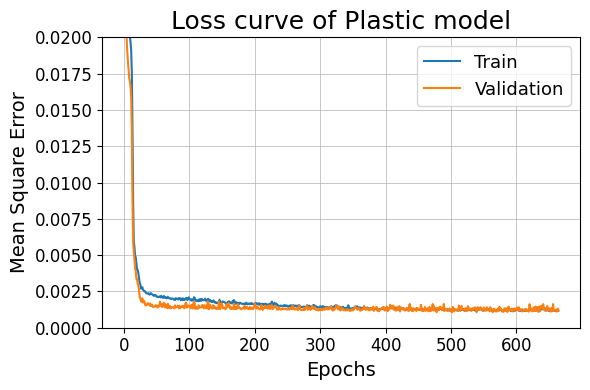

In [22]:
# 將訓練過程圖像化 - Loss

plt.figure(figsize=(6,4))
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('Loss curve of Plastic model', fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,0.02)
plt.grid(linewidth=0.5)
plt.legend(['Train', 'Validation'], fontsize=13)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Mean Square Error', fontsize=14)
# plt.ylabel('Loss', fontsize=14)
plt.tight_layout()
# plt.savefig('Loss.png')
plt.show()

In [105]:
import torch

# 1. 先把模型架構「叫」出來 (必須使用我們剛剛修正過維度錯誤的那個 Class)
# 確保您的程式碼中有定義 PlasticModel 類別
model = PlasticModel() 

# 2. 載入權重檔案
# map_location='cpu' 是為了防止您在 GPU 訓練但在 CPU 電腦上跑預測時出錯
checkpoint_path = 'plastic_model_pytorch.pth'
try:
    model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))
    print(f"✅ 成功載入模型: {checkpoint_path}")
except FileNotFoundError:
    print(f"❌ 找不到檔案: {checkpoint_path} (請確認剛剛訓練有沒有成功存檔)")

# 3. 切換到「評估模式」 (非常重要！)
# 這會凍結 Dropout 和 BatchNorm，否則預測結果會不穩定
model = model.to(device)
model.eval()

✅ 成功載入模型: plastic_model_pytorch.pth


PlasticModel(
  (conv1): Conv2d(1, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (relu): ReLU()
  (conv2): Conv2d(3, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(3, 2, kernel_size=(2, 2), stride=(2, 2))
  (conv4): Conv2d(2, 2, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=1, padding=1, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (img_dense_block): Sequential(
    (0): Linear(in_features=18, out_features=960, bias=True)
    (1): ReLU()
    (2): Linear(in_features=960, out_features=480, bias=True)
    (3): ReLU()
    (4): Linear(in_features=480, out_features=240, bias=True)
    (5): ReLU()
    (6): Linear(in_features=240, out_features=120, bias=True)
    (7): ReLU()
  )
  (info_dense_block): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=48, bi

In [106]:
# ==========================================
# 進行預測與指標計算
# ==========================================
all_predictions = []
all_ground_truth = []

print("開始進行雙階段模型(CompositeDualModel)評估與指標計算...")

with torch.no_grad(): 
    # 使用與訓練時相同的 val_loader
    for img_batch, info_batch, target_batch in val_loader:
        img_batch, info_batch = img_batch.to(device), info_batch.to(device)
        
        # 雙階段模型的前向傳播
        outputs = model(img_batch, info_batch)
        
        # 收集預測結果與真實值
        all_predictions.append(outputs.cpu().numpy())
        all_ground_truth.append(target_batch.cpu().numpy())

# 將收集到的批次數據還原為完整的 NumPy 矩陣
all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

# ==========================================
# 反正規化與物理指標計算
# ==========================================
# 1. 進行反正規化還原為真實物理尺度
y_val_inverse = Y_minMax.inverse_transform(all_ground_truth)
mlp_preds_inverse = Y_minMax.inverse_transform(all_predictions)

# 2. 萃取三大物理指標 (請確保 calculate_physical_properties 已在上方定義)
true_e, true_p, true_area = calculate_physical_properties(y_val_inverse)
mlp_e, mlp_p, mlp_area = calculate_physical_properties(mlp_preds_inverse)

# 3. 加入防止除以零的微小值
epsilon = 1e-8

# 4. 分別計算彈性斜率、塑性斜率與韌性的評估指標
mlp_r2_e = r2_score(true_e, mlp_e)
mlp_mae_e = mean_absolute_error(true_e, mlp_e)
mlp_mre_e = np.mean(np.abs((true_e - mlp_e) / (true_e + epsilon))) * 100

mlp_r2_p = r2_score(true_p, mlp_p)
mlp_mae_p = mean_absolute_error(true_p, mlp_p)
mlp_mre_p = np.mean(np.abs((true_p - mlp_p) / (true_p + epsilon))) * 100

mlp_r2_area = r2_score(true_area, mlp_area)
mlp_mae_area = mean_absolute_error(true_area, mlp_area)
mlp_mre_area = np.mean(np.abs((true_area - mlp_area) / (true_area + epsilon))) * 100

# ==========================================
# 印出評估結果
# ==========================================
print("\n[Flattened MLP] 塑性模型物理指標評估結果")
print(f"  [彈性斜率] R2 Score: {mlp_r2_e:.4f}, MAE: {mlp_mae_e:.4e}, MRE: {mlp_mre_e:.2f}%")
print(f"  [塑性斜率] R2 Score: {mlp_r2_p:.4f}, MAE: {mlp_mae_p:.4e}, MRE: {mlp_mre_p:.2f}%")
print(f"  [韌性/應變能] R2 Score: {mlp_r2_area:.4f}, MAE: {mlp_mae_area:.4e}, MRE: {mlp_mre_area:.2f}%")

開始進行雙階段模型(CompositeDualModel)評估與指標計算...

[Flattened MLP] 塑性模型物理指標評估結果
  [彈性斜率] R2 Score: 0.9802, MAE: 1.1980e+09, MRE: 2.52%
  [塑性斜率] R2 Score: 0.9640, MAE: 1.7767e+09, MRE: 7.67%
  [韌性/應變能] R2 Score: 0.9783, MAE: 1.5759e+02, MRE: 3.80%


In [24]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"正在使用裝置: {device}")

model.to(device)
# 1. 確保模型在評估模式 (這會關閉 Dropout)
model.eval()

# 2. 準備數據：將 Numpy 轉為 Tensor 並搬移到 GPU
# 假設 x_train_image 等變數目前是 Numpy Arrays

# --- 處理訓練集 (Train) ---
# 注意 dtype=torch.float32 是必須的
x_train_img_tensor = torch.tensor(x_train_image, dtype=torch.float32).to(device)
x_train_info_tensor = torch.tensor(x_train, dtype=torch.float32).to(device)

# --- 處理測試集 (Test) ---
x_test_img_tensor = torch.tensor(x_test_image, dtype=torch.float32).to(device)
x_test_info_tensor = torch.tensor(x_test, dtype=torch.float32).to(device)

# 3. 執行預測 (Inference)
with torch.no_grad(): # 告訴 PyTorch 不要計算梯度，節省記憶體並加速
    # 預測訓練集
    train_output = model(x_train_img_tensor, x_train_info_tensor)
    # 將 Tensor 搬回 CPU 並轉成 Numpy
    y_pred = train_output.cpu().numpy()

    # 預測測試集
    test_output = model(x_test_img_tensor, x_test_info_tensor)
    y_pred_test = test_output.cpu().numpy()

# 4. 形狀確認 (Optional)
# PyTorch 出來的形狀通常已經是 (N, 12)，不需要像 Keras 有時候要硬 reshape
# 但為了保險起見，保留您的 reshape 邏輯也沒問題
# y_pred = y_pred.reshape(2550, 40)
# y_pred_test = y_pred_test.reshape(450, 40)

print(f"y_pred shape: {y_pred.shape}")         # 預期 (2550, 40)
print(f"y_pred_test shape: {y_pred_test.shape}") # 預期 (450, 40)
# 5. 反標準化 (Inverse Transform)
# 這部分跟原本一模一樣，因為 Y_minMax 是 Scikit-Learn 的物件，吃的是 Numpy
y_pred_inverse = Y_minMax.inverse_transform(y_pred)
y_train_inverse = Y_minMax.inverse_transform(y_train)

y_pred_test_inverse = Y_minMax.inverse_transform(y_pred_test)
y_test_inverse = Y_minMax.inverse_transform(y_test)

# 檢查一下結果
print("✅ 預測與反標準化完成")
print(f"Sample Prediction (Inverse): {y_pred_inverse[0]}")

正在使用裝置: cuda
y_pred shape: (2975, 40)
y_pred_test shape: (525, 40)
✅ 預測與反標準化完成
Sample Prediction (Inverse): [1.2139496e+06 2.4658057e-05 2.4235070e+06 4.9307560e-05 3.6174692e+06
 7.3939031e-05 4.7296270e+06 9.8610057e-05 5.7006580e+06 1.2322659e-04
 6.5206360e+06 1.4793240e-04 7.2752435e+06 1.7258791e-04 7.9859805e+06
 1.9720633e-04 8.6678230e+06 2.2183766e-04 9.3292700e+06 2.4656887e-04
 1.0003100e+07 2.7108451e-04 1.0668501e+07 2.9582746e-04 1.1292459e+07
 3.2047392e-04 1.1918002e+07 3.4516110e-04 1.2569914e+07 3.6984243e-04
 1.3237097e+07 3.9445853e-04 1.3891690e+07 4.1895671e-04 1.4513531e+07
 4.4374424e-04 1.5154726e+07 4.6840540e-04 1.5782964e+07 4.9298629e-04]


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# --- 定義評估函數 ---
def evaluate_performance(y_true, y_pred, dataset_name="Dataset"):
    """
    計算並列印回歸指標：R2, MSE, RMSE, MAE
    """
    # 1. 計算各項指標
    # r2_score 在多輸出時，預設是計算每一欄的 R2 然後取平均 (uniform_average)
    r2 = r2_score(y_true, y_pred) 
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    # 2. 列印結果
    print(f"--- {dataset_name} 評估結果 ---")
    print(f"🔹 R2 Score (決定係數): {r2:.5f}")
    print(f"🔹 MSE      (均方誤差): {mse:.5f}")
    print(f"🔹 RMSE   (均方根誤差): {rmse:.5f}")
    print(f"🔹 MAE    (平均絕對誤差): {mae:.5f}")
    print("-" * 30)
    
    return r2, mse, rmse, mae

# ==========================================
# 1. 數值評估 (Numerical Evaluation)
# ==========================================

print("正在計算誤差指標...\n")

# 評估訓練集
train_metrics = evaluate_performance(y_train_inverse, y_pred_inverse, "訓練集 (Train)")

# 評估測試集
test_metrics = evaluate_performance(y_test_inverse, y_pred_test_inverse, "測試集 (Test)")


正在計算誤差指標...

--- 訓練集 (Train) 評估結果 ---
🔹 R2 Score (決定係數): 0.74672
🔹 MSE      (均方誤差): 162157731014.41949
🔹 RMSE   (均方根誤差): 402688.13121
🔹 MAE    (平均絕對誤差): 164797.26455
------------------------------
--- 測試集 (Test) 評估結果 ---
🔹 R2 Score (決定係數): 0.71109
🔹 MSE      (均方誤差): 201496617129.20490
🔹 RMSE   (均方根誤差): 448883.74567
🔹 MAE    (平均絕對誤差): 180850.56335
------------------------------


正在繪製隨機樣本檢查...



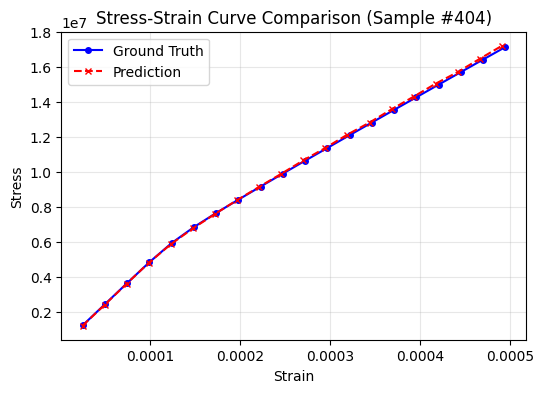

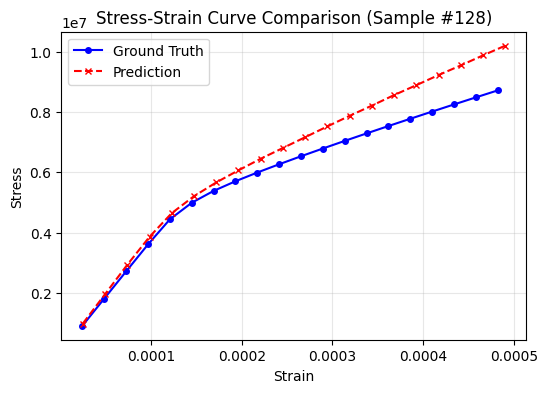

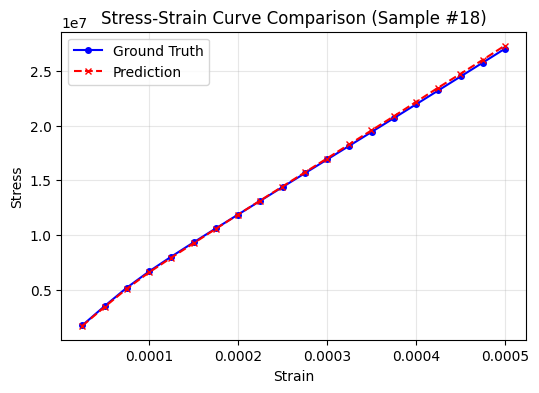

In [26]:
# ==========================================
# 2. 視覺化抽樣檢查 (Visual Check) - 這一步對曲線預測很重要
# ==========================================
# 由於您的輸出是 (Stress, Strain) 交錯的點，畫出來比較能看出是否「平滑」
# 假設順序是: Stress1, Strain1, Stress2, Strain2 ... Stress20, Strain20

def plot_sample_curve(y_true_sample, y_pred_sample, sample_id):
    """
    將 40 個點還原成 20 個 (Strain, Stress) 座標並繪圖
    """
    # 分離 Stress 和 Strain
    # 偶數索引是 Stress (0, 2, 4...)
    # 奇數索引是 Strain (1, 3, 5...)
    
    stress_true = y_true_sample[0::2]
    strain_true = y_true_sample[1::2]
    
    stress_pred = y_pred_sample[0::2]
    strain_pred = y_pred_sample[1::2]
    
    plt.figure(figsize=(6, 4))
    
    # 畫出真實曲線 (藍色實線)
    plt.plot(strain_true, stress_true, 'b-o', label='Ground Truth', markersize=4)
    
    # 畫出預測曲線 (紅色虛線)
    plt.plot(strain_pred, stress_pred, 'r--x', label='Prediction', markersize=4)
    
    plt.title(f"Stress-Strain Curve Comparison (Sample #{sample_id})")
    plt.xlabel("Strain")
    plt.ylabel("Stress")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 隨機抽取 3 個測試集樣本來畫圖
print("正在繪製隨機樣本檢查...\n")
import random
random_indices = random.sample(range(len(y_test_inverse)), 3)

for idx in random_indices:
    plot_sample_curve(y_test_inverse[idx], y_pred_test_inverse[idx], idx)

In [28]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# 1. 確保計算函數已定義 (沿用之前的邏輯)
def calculate_physical_properties(y_data):
    # 分離 Stress (偶數欄) 與 Strain (奇數欄)
    stress = y_data[:, 0::2]
    strain = y_data[:, 1::2]

    # A. 彈性斜率 (Elastic Slope) - 前兩點
    d_stress_e = stress[:, 1] - stress[:, 0]
    d_strain_e = strain[:, 1] - strain[:, 0]
    elastic_slope = np.divide(d_stress_e, d_strain_e, out=np.zeros_like(d_stress_e), where=d_strain_e!=0)

    # B. 塑性斜率 (Plastic Slope) - 最後兩點
    d_stress_p = stress[:, -1] - stress[:, -2]
    d_strain_p = strain[:, -1] - strain[:, -2]
    plastic_slope = np.divide(d_stress_p, d_strain_p, out=np.zeros_like(d_stress_p), where=d_strain_p!=0)

    # C. 韌性 (Toughness) - 曲線下面積
    toughness = np.trapezoid(stress, x=strain, axis=1)

    return elastic_slope, plastic_slope, toughness

# --- 2. 執行計算 ---

# 訓練集 (Train)
train_true_e, train_true_p, train_true_area = calculate_physical_properties(y_train_inverse)
train_pred_e, train_pred_p, train_pred_area = calculate_physical_properties(y_pred_inverse)

# 測試集 (Test)
test_true_e, test_true_p, test_true_area = calculate_physical_properties(y_test_inverse)
test_pred_e, test_pred_p, test_pred_area = calculate_physical_properties(y_pred_test_inverse)


NameError: name 'y_train_inverse' is not defined

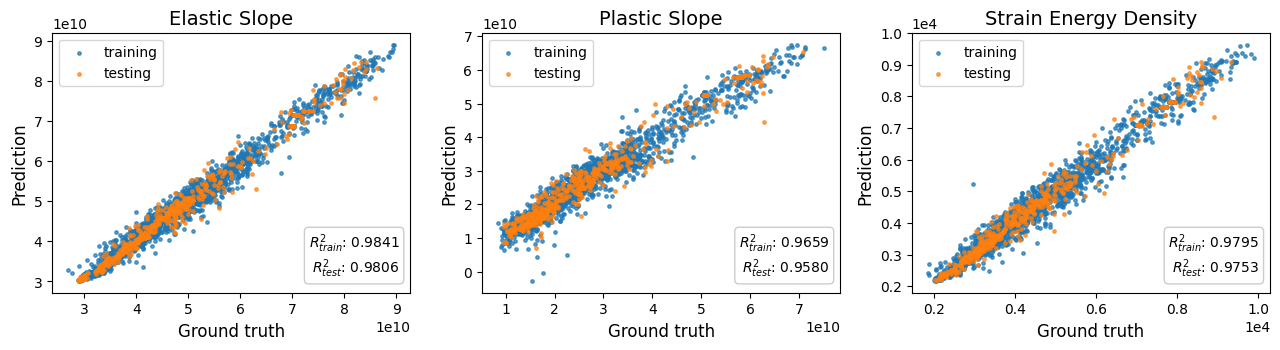

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 將您的變數打包成清單
train_true_list = [train_true_e, train_true_p, train_true_area]
train_pred_list = [train_pred_e, train_pred_p, train_pred_area]

test_true_list = [test_true_e, test_true_p, test_true_area]
test_pred_list = [test_pred_e, test_pred_p, test_pred_area]

# 設定三個子圖的標題：彈性段斜率、塑性段斜率、曲線下面積(應變能)
# 將第三個標題精確修正為應變能密度
titles = ['Elastic Slope', 'Plastic Slope', 'Strain Energy Density']

# 建立 1 列 3 行的畫布，寬度保持 14，高度縮為 3 (與前一張圖的單列比例完全一致)
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

for i in range(3):
    # 繪製散佈圖 (點大小設為 6，與前一張 4x3 的設定保持一致)
    ax[i].scatter(train_true_list[i], train_pred_list[i], s=6, alpha=0.7, label='training')
    ax[i].scatter(test_true_list[i], test_pred_list[i], s=6, alpha=0.7, label='testing')
    
    # 設定標題與軸標籤
    ax[i].set_title(titles[i], fontsize=14)
    ax[i].set_xlabel('Ground truth', fontsize=12)
    ax[i].set_ylabel('Prediction', fontsize=12)
    
    # 強制使用科學記號
    ax[i].ticklabel_format(style='sci', scilimits=(0, 0), axis='both')
    
    # 固定圖例在左上角
    ax[i].legend(loc='upper left', fontsize=10)
    
    # 計算並格式化 R2 分數
    r2_train = r2_score(train_true_list[i], train_pred_list[i])
    r2_test = r2_score(test_true_list[i], test_pred_list[i])
    text_str = f'$R^2_{{train}}$: {r2_train:.4f}\n$R^2_{{test}}$: {r2_test:.4f}'
    
    # 在右下角加入 R2 文字方塊
    ax[i].text(0.97, 0.05, text_str, transform=ax[i].transAxes, 
               fontsize=10, verticalalignment='bottom', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

# 調整子圖間的左右間距與邊界，對齊上一張圖的視覺比例
plt.subplots_adjust(left=0.08, right=0.95, bottom=0.2, top=0.85, wspace=0.2)

plt.show()

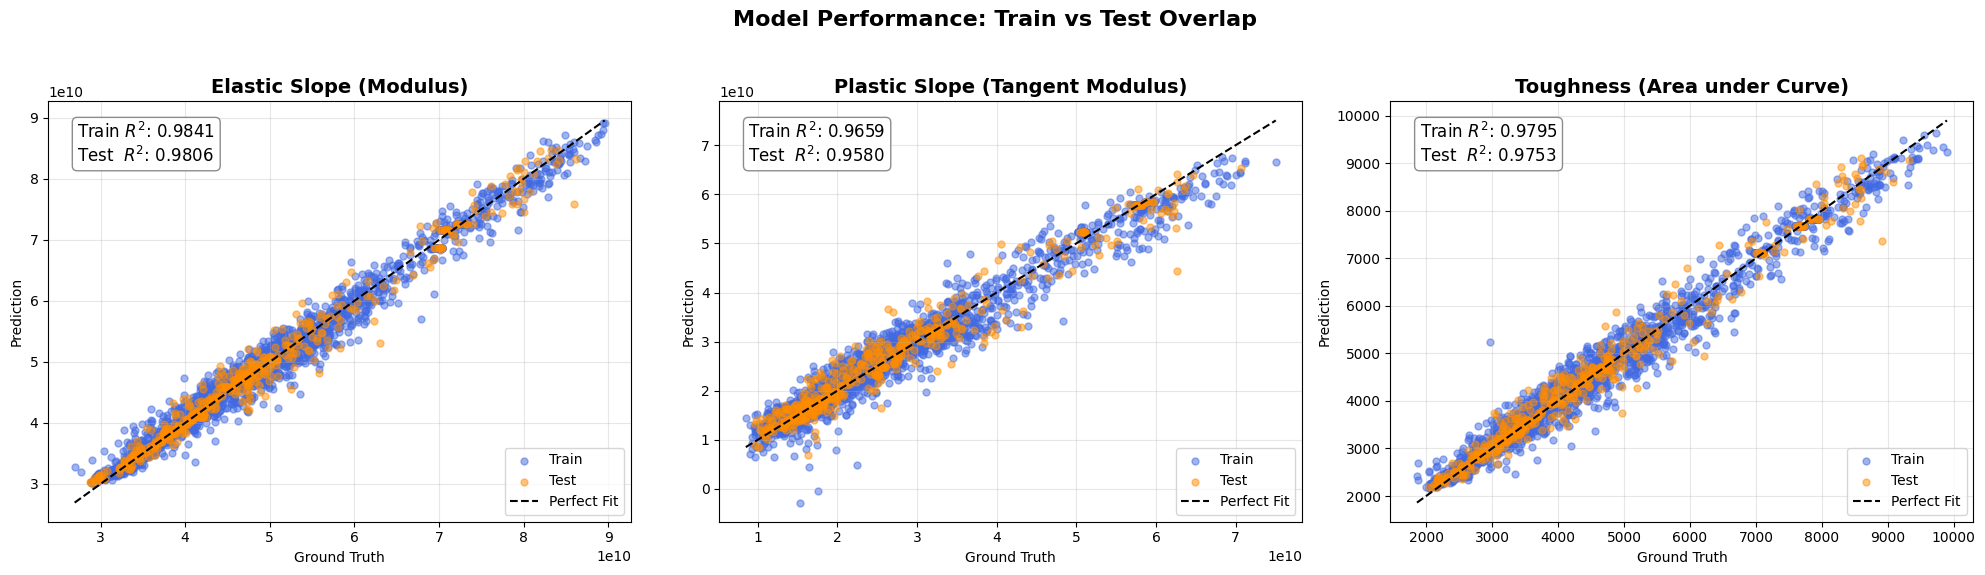

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

# 設定畫布大小 (寬一點比較好放三張圖)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# 設定整體標題
fig.suptitle('Model Performance: Train vs Test Overlap', fontsize=16, fontweight='bold')

def plot_combined_scatter(ax, train_true, train_pred, test_true, test_pred, title):
    """
    功能: 將訓練與測試數據畫在同一張散點圖上，並標註 R2
    """
    # 1. 計算 R2
    r2_train = r2_score(train_true, train_pred)
    r2_test = r2_score(test_true, test_pred)
    
    # 2. 畫散點圖
    # 訓練集: 藍色，透明度高一點，因為點多
    ax.scatter(train_true, train_pred, c='royalblue', alpha=0.5, s=25, label='Train')
    # 測試集: 橘色叉叉，透明度低一點，強調顯示
    ax.scatter(test_true, test_pred, c='darkorange', alpha=0.5, s=25, marker='o', label='Test')
    
    # 3. 畫 y=x 參考線 (完美預測線)
    # 找出所有數據的最小值與最大值
    all_min = min(np.min(train_true), np.min(test_true))
    all_max = max(np.max(train_true), np.max(test_true))
    ax.plot([all_min, all_max], [all_min, all_max], 'k--', lw=1.5, label='Perfect Fit')
    
    # 4. 加上 R2 文字標籤 (左上角)
    text_str = f'Train $R^2$: {r2_train:.4f}\nTest  $R^2$: {r2_test:.4f}'
    # 使用 bbox 讓文字有個白底框，避免被點遮住
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    # 5. 設定標題與軸標籤
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Prediction")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

# --- 執行繪圖 ---

# 1. 彈性斜率 (Elastic Slope)
plot_combined_scatter(axes[0], 
                      train_true_e, train_pred_e, 
                      test_true_e, test_pred_e, 
                      "Elastic Slope (Modulus)")

# 2. 塑性斜率 (Plastic Slope)
plot_combined_scatter(axes[1], 
                      train_true_p, train_pred_p, 
                      test_true_p, test_pred_p, 
                      "Plastic Slope (Tangent Modulus)")

# 3. 韌性/面積 (Toughness)
plot_combined_scatter(axes[2], 
                      train_true_area, train_pred_area, 
                      test_true_area, test_pred_area, 
                      "Toughness (Area under Curve)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局
plt.show()

## 不同模型基準測試

### --- MLP model ---

In [22]:
import torch
import torch.nn as nn

class FlattenedMLP(nn.Module):
    def __init__(self, img_elements=25, info_features=25, out_features=40):
        super(FlattenedMLP, self).__init__()
        
        # 5x5 矩陣攤平為 25，加上 25 個數值特徵，總輸入維度為 46
        in_features = img_elements + info_features
        
        # 使用與原本 Dual-Stage 融合後相似的 Dense Layer 架構以確保參數規模公平
        self.mlp = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, out_features)
        )

    def forward(self, x_img, x_info):
        # x_img shape 預期為 (batch_size, 1, 5, 5) 或 (batch_size, 5, 5)
        # 保持 batch_size 維度，將影像矩陣攤平
        x_img_flat = x_img.view(x_img.size(0), -1) 
        
        # 將攤平的影像特徵與數值特徵在特徵維度(dim=1)合併
        x_combined = torch.cat((x_img_flat, x_info), dim=1)
        
        # 通過純多層感知機
        out = self.mlp(x_combined)
        return out


In [23]:
import time
import torch
import torch.nn as nn

# 設定訓練參數
epochs = 3000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 初始化模型、優化器、損失函數
# 注意：這裡改用基準比較的 FlattenedMLP
model = FlattenedMLP().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1e-7) 
criterion = nn.MSELoss() 

# 初始化早停物件 (假設 EarlyStopper 已經在前面定義好)
early_stopper = EarlyStopper(patience=100)

# 開始計時
start = time.time()
print("Training started...")

# 變數名稱加上 mlp 區分
history_mlp = {'loss': [], 'val_loss': []} 

for epoch in range(epochs):
    # - 訓練階段 (Training) -
    model.train()
    running_loss = 0.0
    for img_batch, info_batch, target_batch in train_loader:
        # 搬移數據到 GPU
        img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
        
        # 1. 歸零梯度
        optimizer.zero_grad()
        
        # 2. 前向傳播
        # FlattenedMLP 內部會自動把 img_batch 攤平並與 info_batch 合併，所以這裡直接傳入即可
        outputs = model(img_batch, info_batch)
        
        # 3. 計算 Loss
        loss = criterion(outputs, target_batch)
        
        # 4. 反向傳播
        loss.backward()
        
        # 5. 更新權重
        optimizer.step()
        
        running_loss += loss.item() * img_batch.size(0) # 累加 Loss
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # - 驗證階段 (Validation) -
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad(): # 驗證時不需要計算梯度，節省記憶體
        for img_batch, info_batch, target_batch in val_loader:
            img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
            outputs = model(img_batch, info_batch)
            loss = criterion(outputs, target_batch)
            val_running_loss += loss.item() * img_batch.size(0)
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    
    # - 紀錄與印出 -
    history_mlp['loss'].append(epoch_loss)
    history_mlp['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f} - val_loss: {epoch_val_loss:.6f}")
    
    # - 檢查早停與存檔 -
    if early_stopper.early_stop(epoch_val_loss, model):
        print("Early stopping triggered!")
        break

# 恢復最佳權重
early_stopper.load_best_weights(model)

# 最終存檔 (修改存檔檔名避免覆蓋原本的模型)
# torch.save(model.state_dict(), 'baseline_mlp_model.pth')

end = time.time()
print('Training has finished')
print('spend time is : ', end-start)

Using device: cuda
Training started...
Epoch 1/3000 - loss: 0.297441 - val_loss: 0.083267
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 2/3000 - loss: 0.047526 - val_loss: 0.034703
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 3/3000 - loss: 0.029711 - val_loss: 0.020399
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 4/3000 - loss: 0.020243 - val_loss: 0.015828
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 5/3000 - loss: 0.016540 - val_loss: 0.013587
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 6/3000 - loss: 0.014196 - val_loss: 0.012121
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 7/3000 - loss: 0.012696 - val_loss: 0.010816
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 8/3000 - loss: 0.011363 - val_loss: 0.009673
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 9/3000 - loss: 0.010077 - val_loss: 0.008408
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 10/3000 - 

In [104]:
import numpy as np
import torch
from sklearn.metrics import r2_score, mean_absolute_error

# 將模型切換至評估模式
model.eval()

# 用來儲存所有批次的預測結果與真實標籤
all_predictions = []
all_ground_truth = []

print("開始進行模型評估與指標計算...")

# 驗證階段不需要計算梯度
with torch.no_grad(): 
    for img_batch, info_batch, target_batch in val_loader:
        # 將輸入數據移至指定裝置 (GPU 或 CPU)
        img_batch, info_batch = img_batch.to(device), info_batch.to(device)
        
        # 前向傳播計算預測值
        outputs = model(img_batch, info_batch)
        
        # 將預測結果與真實值移回 CPU 並轉換為 NumPy 陣列
        all_predictions.append(outputs.cpu().numpy())
        all_ground_truth.append(target_batch.cpu().numpy())

# 將所有批次的數據垂直堆疊，還原成完整的矩陣格式
all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

# ==========================================
# 反正規化與物理指標計算
# ==========================================
# 1. 進行反正規化還原為真實物理尺度
y_val_inverse = Y_minMax.inverse_transform(all_ground_truth)
mlp_preds_inverse = Y_minMax.inverse_transform(all_predictions)

# 2. 萃取三大物理指標 (請確保 calculate_physical_properties 已在上方定義)
true_e, true_p, true_area = calculate_physical_properties(y_val_inverse)
mlp_e, mlp_p, mlp_area = calculate_physical_properties(mlp_preds_inverse)

# 3. 加入防止除以零的微小值
epsilon = 1e-8

# 4. 分別計算彈性斜率、塑性斜率與韌性的評估指標
mlp_r2_e = r2_score(true_e, mlp_e)
mlp_mae_e = mean_absolute_error(true_e, mlp_e)
mlp_mre_e = np.mean(np.abs((true_e - mlp_e) / (true_e + epsilon))) * 100

mlp_r2_p = r2_score(true_p, mlp_p)
mlp_mae_p = mean_absolute_error(true_p, mlp_p)
mlp_mre_p = np.mean(np.abs((true_p - mlp_p) / (true_p + epsilon))) * 100

mlp_r2_area = r2_score(true_area, mlp_area)
mlp_mae_area = mean_absolute_error(true_area, mlp_area)
mlp_mre_area = np.mean(np.abs((true_area - mlp_area) / (true_area + epsilon))) * 100

# ==========================================
# 印出評估結果
# ==========================================
print("\n[Flattened MLP] 塑性模型物理指標評估結果")
print(f"  [彈性斜率] R2 Score: {mlp_r2_e:.4f}, MAE: {mlp_mae_e:.4e}, MRE: {mlp_mre_e:.2f}%")
print(f"  [塑性斜率] R2 Score: {mlp_r2_p:.4f}, MAE: {mlp_mae_p:.4e}, MRE: {mlp_mre_p:.2f}%")
print(f"  [韌性/應變能] R2 Score: {mlp_r2_area:.4f}, MAE: {mlp_mae_area:.4e}, MRE: {mlp_mre_area:.2f}%")

開始進行模型評估與指標計算...

[Flattened MLP] 塑性模型物理指標評估結果
  [彈性斜率] R2 Score: 0.9357, MAE: 2.3404e+09, MRE: 4.89%
  [塑性斜率] R2 Score: 0.2362, MAE: 8.8622e+09, MRE: 40.12%
  [韌性/應變能] R2 Score: 0.9438, MAE: 2.8013e+02, MRE: 6.75%


### --- RandomForest model ---

In [29]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 步驟 1：資料格式轉換與攤平
# ==========================================
X_img_train_flat = X_img_train_split.reshape(X_img_train_split.shape[0], -1)
X_train_ml = np.concatenate((X_img_train_flat, X_info_train_split), axis=1) 

X_img_val_flat = X_img_val_split.reshape(X_img_val_split.shape[0], -1)
X_val_ml = np.concatenate((X_img_val_flat, X_info_val_split), axis=1)       

y_train_ml = y_train_split
y_val_ml = y_val_split

# ==========================================
# 步驟 2：訓練 Random Forest (隨機森林)
# ==========================================
print("開始訓練 Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_ml, y_train_ml)
rf_preds = rf_model.predict(X_val_ml)

# ==========================================
# 步驟 3：反正規化與物理指標計算
# ==========================================
# 1. 進行反正規化還原為真實物理尺度
y_val_inverse = Y_minMax.inverse_transform(y_val_ml)
rf_preds_inverse = Y_minMax.inverse_transform(rf_preds)

# 2. 萃取三大物理指標 (請確保 calculate_physical_properties 已在上方定義)
true_e, true_p, true_area = calculate_physical_properties(y_val_inverse)
rf_e, rf_p, rf_area = calculate_physical_properties(rf_preds_inverse)

# 3. 加入防止除以零的微小值
epsilon = 1e-8

# 4. 分別計算彈性斜率、塑性斜率與韌性的評估指標
rf_r2_e = r2_score(true_e, rf_e)
rf_mae_e = mean_absolute_error(true_e, rf_e)
rf_mre_e = np.mean(np.abs((true_e - rf_e) / (true_e + epsilon))) * 100

rf_r2_p = r2_score(true_p, rf_p)
rf_mae_p = mean_absolute_error(true_p, rf_p)
rf_mre_p = np.mean(np.abs((true_p - rf_p) / (true_p + epsilon))) * 100

rf_r2_area = r2_score(true_area, rf_area)
rf_mae_area = mean_absolute_error(true_area, rf_area)
rf_mre_area = np.mean(np.abs((true_area - rf_area) / (true_area + epsilon))) * 100

print("\n[Random Forest] 塑性模型物理指標評估結果")
print(f"  [彈性斜率] R2 Score: {rf_r2_e:.4f}, MAE: {rf_mae_e:.4e}, MRE: {rf_mre_e:.2f}%")
print(f"  [塑性斜率] R2 Score: {rf_r2_p:.4f}, MAE: {rf_mae_p:.4e}, MRE: {rf_mre_p:.2f}%")
print(f"  [韌性/應變能] R2 Score: {rf_r2_area:.4f}, MAE: {rf_mae_area:.4e}, MRE: {rf_mre_area:.2f}%")

開始訓練 Random Forest...

[Random Forest] 塑性模型物理指標評估結果
  [彈性斜率] R2 Score: 0.9611, MAE: 1.7186e+09, MRE: 3.72%
  [塑性斜率] R2 Score: 0.9562, MAE: 1.9127e+09, MRE: 8.29%
  [韌性/應變能] R2 Score: 0.9612, MAE: 2.1012e+02, MRE: 5.15%


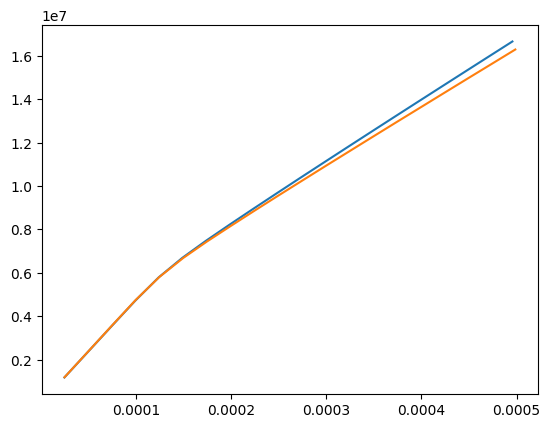

In [103]:
import random

num = random.randint(0, 447)

plt.plot(rf_preds_inverse[num][1::2], rf_preds_inverse[num][::2])
plt.plot(y_val_inverse[num][1::2], y_val_inverse[num][::2])

### --- XGBoost ---

In [31]:
# ==========================================
# 步驟 3：訓練 XGBoost
# ==========================================
print("\n開始訓練 XGBoost...")
# XGBoost 預設只支援單一輸出，必須包裝進 MultiOutputRegressor
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model = MultiOutputRegressor(xgb_base)
xgb_model.fit(X_train_ml, y_train_ml)
xgb_preds = xgb_model.predict(X_val_ml)

# ==========================================
# 步驟 4：反正規化與物理指標計算 (XGBoost)
# ==========================================
# 1. 進行反正規化還原為真實物理尺度
# (如果上方隨機森林已經計算過 y_val_inverse，這裡其實可以直接沿用，但為了程式碼完整性保留)
y_val_inverse = Y_minMax.inverse_transform(y_val_ml)
xgb_preds_inverse = Y_minMax.inverse_transform(xgb_preds)

# 2. 萃取三大物理指標
true_e, true_p, true_area = calculate_physical_properties(y_val_inverse)
xgb_e, xgb_p, xgb_area = calculate_physical_properties(xgb_preds_inverse)

# 3. 加入防止除以零的微小值
epsilon = 1e-8

# 4. 分別計算彈性斜率、塑性斜率與韌性的評估指標
xgb_r2_e = r2_score(true_e, xgb_e)
xgb_mae_e = mean_absolute_error(true_e, xgb_e)
xgb_mre_e = np.mean(np.abs((true_e - xgb_e) / (true_e + epsilon))) * 100

xgb_r2_p = r2_score(true_p, xgb_p)
xgb_mae_p = mean_absolute_error(true_p, xgb_p)
xgb_mre_p = np.mean(np.abs((true_p - xgb_p) / (true_p + epsilon))) * 100

xgb_r2_area = r2_score(true_area, xgb_area)
xgb_mae_area = mean_absolute_error(true_area, xgb_area)
xgb_mre_area = np.mean(np.abs((true_area - xgb_area) / (true_area + epsilon))) * 100

print("\n[XGBoost] 塑性模型物理指標評估結果")
print(f"  [彈性斜率] R2 Score: {xgb_r2_e:.4f}, MAE: {xgb_mae_e:.4e}, MRE: {xgb_mre_e:.2f}%")
print(f"  [塑性斜率] R2 Score: {xgb_r2_p:.4f}, MAE: {xgb_mae_p:.4e}, MRE: {xgb_mre_p:.2f}%")
print(f"  [韌性/應變能] R2 Score: {xgb_r2_area:.4f}, MAE: {xgb_mae_area:.4e}, MRE: {xgb_mre_area:.2f}%")


開始訓練 XGBoost...

[XGBoost] 塑性模型物理指標評估結果
  [彈性斜率] R2 Score: 0.9720, MAE: 1.4022e+09, MRE: 3.00%
  [塑性斜率] R2 Score: 0.3604, MAE: 7.5447e+09, MRE: 33.67%
  [韌性/應變能] R2 Score: 0.9711, MAE: 1.8269e+02, MRE: 4.43%


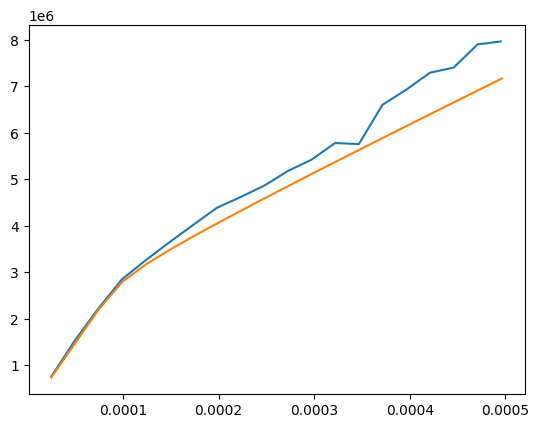

In [75]:
import random

num = random.randint(0, 447)

plt.plot(xgb_preds_inverse[num][1::2], xgb_preds_inverse[num][::2])
plt.plot(y_val_inverse[num][1::2], y_val_inverse[num][::2])